Desplazamiento

In [3]:
import pandas as pd
ds = pd.read_csv("Salarios_minimos.csv")
ds.describe

<bound method NDFrame.describe of     Periodo  Salario
0   1988.25     8.00
1   1989.00     8.64
2   1989.50     9.16
3   1990.00    10.08
4   1990.84    11.90
5   1991.84    13.33
6   1993.00    14.27
7   1994.00    15.27
8   1995.00    16.34
9   1995.30    18.30
10  1996.00    20.15
11  1996.30    22.60
12  1997.00    26.45
13  1998.00    30.20
14  1999.00    34.45
15  2000.00    37.90
16  2001.00    40.35
17  2002.00    42.15
18  2003.00    43.65
19  2004.00    45.24
20  2005.00    46.80
21  2006.00    48.67
22  2007.00    50.57
23  2008.00    52.59
24  2009.00    54.80
25  2010.00    57.46
26  2011.00    59.82
27  2012.00    62.33
28  2013.00    64.76
29  2014.00    67.29
30  2015.00    70.10
31  2016.00    73.04
32  2017.00    80.04
33  2018.00    88.36>

In [5]:
import numpy as np
t1 = np.reshape(ds["Periodo"] - 1988, (34,1))  
t1 = t_v

In [11]:
from sklearn.linear_model import LinearRegression
s1 = LinearRegression()
s1.fit(t1, ds["Salario"])
print(s1.intercept_)
print(s1.coef_)


3.715577808507625
[2.52832885]


Text(0, 0.5, 'Salario')

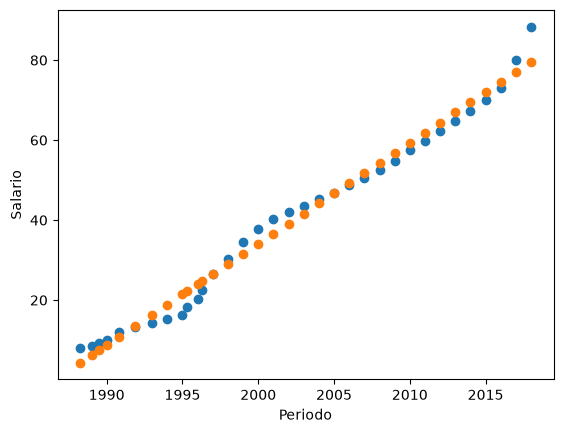

In [14]:
import matplotlib.pyplot as plt
plt.figure ()
plt.scatter(ds["Periodo"], ds["Salario"])
plt.scatter(ds["Periodo"], s1.predict(t1))
plt.xlabel("Periodo")
plt.ylabel("Salario")


In [18]:
periodo_v = np.reshape(ds["Periodo"], (34, 1))
df_diferencia = s1.predict(t1) - s1.predict(periodo_v)
df_diferencia

array([-5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945, -5026.31774945, -5026.31774945,
       -5026.31774945, -5026.31774945])

Escalamiento

MinMax

In [19]:
df = pd.read_csv("bateria_tableta.txt")
df.describe()

,carga,duracion
count,100.000000,100.000000
mean,4.573000,6.206800
std,2.788603,2.454116
min,0.000000,0.000000
25%,1.987500,3.975000
50%,4.375000,8.000000
75%,6.522500,8.000000
max,11.720000,8.000000


In [23]:
carga_min = df["carga"].min()
carga_max = df["carga"].max()

df["carga_m"] = 1 + (df["carga"] - carga_min) / (carga_max - carga_min)
df["carga_m"].describe()

count    100.000000
mean       1.390188
std        0.237935
min        1.000000
25%        1.169582
50%        1.373294
75%        1.556527
max        2.000000
Name: carga_m, dtype: float64

In [24]:

x_v = np.reshape(df["carga_m"], (100,1))
x_2v = x_v**2
x_3v = x_v**3
x_4v = x_v**4
x_5v = x_v**5
x_6v = x_v**6
x_7v = x_v**7
x_8v = x_v**8
x_9v = x_v**9

X9 = np.hstack([x_v, x_2v, x_3v, x_4v, x_5v, x_6v, x_7v, x_8v, x_9v])

lr9 = LinearRegression()
lr9.fit(X9, df["duracion"])
print(lr9.intercept_)
print(lr9.coef_)

25.33943262094415
[-38.7778695  -27.49035908   9.98557454  39.02008643  28.38556741
 -21.14924722 -46.4044648   39.11470934  -8.12990227]


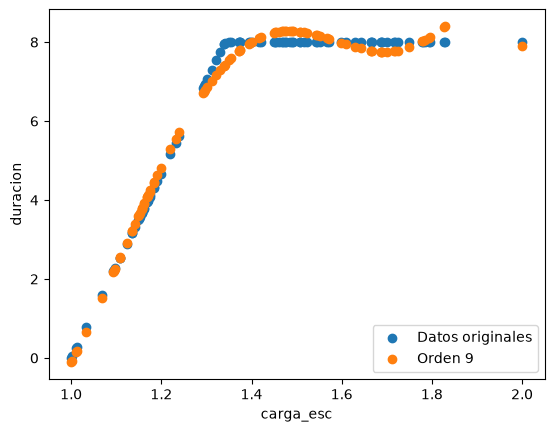

In [25]:

plt.figure()
plt.scatter(df["carga_esc"], df["duracion"], label="Datos originales")
plt.scatter(df["carga_esc"], lr9.predict(X9), label="Orden 9")
plt.xlabel("carga_esc")
plt.ylabel("duracion")
plt.legend()

In [34]:
n = len(df["carga"])
carga_media = np.sum(df["carga"]) / n
carga_std = np.sqrt(np.sum((df["carga"] - carga_media)**2) / n)

df["carga_z"] = (df["carga"] - carga_media) / carga_std
print(df["carga_z"].mean(), df["carga_z"].std())

-1.4210854715202004e-16 1.005037815259212


In [35]:
#regresion 9
x_v = np.reshape(df["carga_z"], (100,1))
x_2v = x_v**2
x_3v = x_v**3
x_4v = x_v**4
x_5v = x_v**5
x_6v = x_v**6
x_7v = x_v**7
x_8v = x_v**8
x_9v = x_v**9

X9 = np.hstack([x_v, x_2v, x_3v, x_4v, x_5v, x_6v, x_7v, x_8v, x_9v])

lr9 = LinearRegression()
lr9.fit(X9, df["duracion"])
print(lr9.intercept_)
print(lr9.coef_)

8.078921730458578
[ 0.86867393 -3.79516836  2.62576058  2.10010957 -1.7262677  -0.69005438
  0.4915431   0.08289328 -0.04960544]


In [37]:
from sklearn.preprocessing import MinMaxScaler
x = np.reshape(ds["Periodo"], (34, 1))
scaler = MinMaxScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)
x_scaled

array([[0.        ],
       [0.02521008],
       [0.04201681],
       [0.05882353],
       [0.08705882],
       [0.12067227],
       [0.15966387],
       [0.19327731],
       [0.22689076],
       [0.23697479],
       [0.2605042 ],
       [0.27058824],
       [0.29411765],
       [0.32773109],
       [0.36134454],
       [0.39495798],
       [0.42857143],
       [0.46218487],
       [0.49579832],
       [0.52941176],
       [0.56302521],
       [0.59663866],
       [0.6302521 ],
       [0.66386555],
       [0.69747899],
       [0.73109244],
       [0.76470588],
       [0.79831933],
       [0.83193277],
       [0.86554622],
       [0.89915966],
       [0.93277311],
       [0.96638655],
       [1.        ]])